Off to a good start but missing the visitor center model.


## Seepage vs Δh Model Comparison


This notebook compares two models for seepage as a function of the water-level difference 
between estuary and ocean Δh, using an effective berm conductance $K$.

We model seepage as:

$$
S \;=\; K(\Delta h)\,\Delta h,
$$
where $(K(\Delta h))$ is an *effective berm conductance*. We compare two alternative models for $(K(\Delta h))$:

- **Constant $(K)$ (linear fit):**
$$
K(\Delta h) \;=\; K 
\quad\Rightarrow\quad
S \;=\; K \cdot \Delta h
$$

- **Offset–power $(K)$ :**
$$
K(\Delta h) \;=\; K \cdot(\Delta h+\text{offset})^{b}
\quad\Rightarrow\quad
S \;=\; K \cdot (\Delta h+\text{offset})^{b} \cdot \Delta h
$$

Here, offset represents an effective $\Delta h$ threshold for flow.


### Model-comparison approaches
1. *Pooled fit*: one parameter set fit to all closure events.  
2. *Per-event fits:* parameters estimated separately within each event; results summarized across events.

### Evaluation
- *Information criteria:* *sum* event-level AIC/BIC for per-event fits (equivalently, sum $(-2\log L$) and add penalties).  
- *Goodness of fit:* report R^2 and RMSE; provide unweighted and duration-weighted summaries across events.


Preliminary 
seepage really strong,
two models
linear model.
based on idea the flow path cross section area doesn't change much with water level
following same pipe eachn time 
depends linearly on h
convenient for management purposes

other model - quadratic, homogeneous sand barrier, gravel, flow cross sectional area should increase with rising water level, dependence close to quadratic, w value flow length doesn't change much with water level
how deep the flow path, whether to compare estuary to mean sea level / mean low tide level.
doesn't seem to matter all that much, general model.

 


## Load daily data
- Parse `delta_h` and `seepage` as numeric.
- Drop NA; enforce `delta_h > 0` (for power terms).


In [26]:
from pathlib import Path
import pandas as pd

# Path to the pooled, event-labeled panel saved as CSV
data_path = Path("../data/processed/pooled_event_df.csv")

# Load the data
pooled_event_df = pd.read_csv(data_path)

# Ensure numeric types; coerce bad parses to NaN (so they can be dropped)
pooled_event_df["delta_h"] = pd.to_numeric(pooled_event_df["delta_h"], errors="coerce")
pooled_event_df["seepage"] = pd.to_numeric(pooled_event_df["seepage"], errors="coerce")

# Drop rows missing either key variable
pooled_event_df = pooled_event_df.dropna(subset=["delta_h", "seepage"])

# Quick peek at the core columns
display(pooled_event_df[["delta_h", "seepage", "event"]].head())
pooled_event_df = pooled_event_df.query("seepage < 4")

# add row-count per event to the original DataFrame
pooled_event_df["n"] = pooled_event_df.groupby("event")["event"].transform("size").astype("int64")
pooled_event_df = pooled_event_df.query("n>5")

# Row count after cleaning (i.e., number of event-days retained)
print(f"Closure days with data: {len(pooled_event_df)}")

median_delta_h = pooled_event_df['delta_h'].median()
median_visitor_h = pooled_event_df['visitor_h'].median()
min_delta_h = pooled_event_df['delta_h'].min()


,delta_h,seepage,event
0,0.728999,0.240583,0
1,0.803515,0.887796,0
2,0.906064,0.896792,0
3,0.966680,0.867753,0
4,1.036316,0.819474,0


Closure days with data: 390


## Helpfer functions

In [27]:
# --- Imports & configuration ---
import numpy as np
import pandas as pd
from pathlib import Path
from scipy.optimize import minimize
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.dpi": 300,
    "figure.figsize": (8, 4.5),
    "axes.grid": True,
    "grid.alpha": 0.3,
})

def r2_centered(y: np.ndarray, yhat: np.ndarray) -> float:
    """Centered R² = 1 − SSE/SST, where SST is around ȳ (fits are through origin)."""
    sse = np.sum((y - yhat)**2)
    sst = np.sum((y - y.mean())**2)
    return 1 - sse/sst if sst > 0 else np.nan

def aic_gaussian(sse: float, n: int, k: int) -> float:
    """AIC for least squares under Gaussian errors: AIC = n·ln(SSE/n) + 2k (lower is better)."""
    return n * np.log(sse / n) + 2 * k

def bic_gaussian(sse: float, n: int, k: int) -> float:
    """BIC for least squares under Gaussian errors: BIC = n·ln(SSE/n) + k·ln(n) (lower is better)."""
    return n * np.log(sse / n) + k * np.log(n)

# Models (through origin)
def model_linear(params: np.ndarray, x: np.ndarray) -> np.ndarray:
    """Linear through origin: S = K · Δh."""
    K = params[0]
    return K * x

def model_power_offset(params: np.ndarray, x: np.ndarray) -> np.ndarray:
    """Offset–power through origin: S = K · Δh · (Δh + offset)^b.
    Note: requires Δh + offset ≥ 0 for non-integer b; enforce upstream if needed."""
    K, offset, b = params

    return K * x * (((x + offset))/median_delta_h)**b

# # --- existing models (unchanged) -------------------------------------------
# def model_linear(params: np.ndarray, x: np.ndarray) -> np.ndarray:
#     """Linear through origin: S = K · Δh."""
#     K = float(params[0])
#     dh, _ = _unpack_x(x)
#     return K * dh

# def model_power_offset(params: np.ndarray, x: np.ndarray) -> np.ndarray:
#     """Offset–power through origin: S = K · Δh · ((Δh + offset)/median_Δh)^b.
#     Note: requires Δh + offset ≥ 0 for non-integer b; enforce upstream if needed."""
#     K, offset, b = params
#     dh, _ = _unpack_x(x)
#     # Safe median scale (avoid /0 and keep units tidy)
#     med_dh = np.nanmedian(dh) if np.isfinite(np.nanmedian(dh)) and np.nanmedian(dh) != 0 else 1.0
#     return K * dh * ((dh + offset) / med_dh) ** b


def sse_linear(params: np.ndarray, x: np.ndarray, y: np.ndarray) -> float:
    """Sum of squared errors for the linear model."""
    return np.sum((y - model_linear(params, x))**2)

def sse_power_offset(params: np.ndarray, x: np.ndarray, y: np.ndarray) -> float:
    """Sum of squared errors for the offset–power model."""
    return np.sum((y - model_power_offset(params, x))**2)

# import numpy as np
# LAMBDA_OFF = 1e-2  # tune 1e-4–1e-1

# --- helpers ---------------------------------------------------------------
def _unpack_x(x):
    """
    Accept either:
      - x: np.ndarray of Δh               (existing models)
      - x: (delta_h, visitor_h) tuple     (new model)
    Returns (delta_h, visitor_h_or_None)
    """
    if isinstance(x, (tuple, list)) and len(x) == 2:
        dh, vh = x
        return np.asarray(dh), np.asarray(vh)
    return np.asarray(x), None



# def sse_power_offset_ridge(params, x, y):
#     K, off, b = params
#     resid = y - model_power_offset(params, x)
#     pen = LAMBDA_OFF * (off**2)
#     return np.sum(resid**2) + pen
# then pass sse_power_offset_ridge to minimize(...)


def sse_linear(params: np.ndarray, x: np.ndarray, y: np.ndarray) -> float:
    return np.sum((y - model_linear(params, x))**2)

def sse_power_offset(params: np.ndarray, x: np.ndarray, y: np.ndarray) -> float:
    return np.sum((y - model_power_offset(params, x))**2)

def sse_visitor(params: np.ndarray, x, y: np.ndarray) -> float:
    """
    SSE for the visitor_h-powered model.
    Enforces (visitor_h + offset) >= 0 by returning +inf if violated.
    """
    _, vh = _unpack_x(x)


    K, offset, b = params
    # Hard guard to keep fractional powers real-valued
    if np.any((vh + offset) < 0):
        return np.inf

    yhat = model_visitor_power_offset(params, x)
    # If any NaNs/Infs appear, penalize strongly
    if not np.all(np.isfinite(yhat)):
        return np.inf

    return np.sum((y - yhat) ** 2)



def model_visitor(params: np.ndarray, x) -> np.ndarray:
    """
    Third option:
        S = K · Δh · ((visitor_h + offset)/median_visitor_h)^b

    x should be a tuple: (delta_h, visitor_h).
    For safety, if visitor_h + offset < 0 anywhere (non-integer b), the caller's SSE
    should penalize those params (we do that in the SSE).
    """
    K, offset, b = params
    dh, vh = _unpack_x(x)

    return K * dh * ((vh + offset) / median_visitor_h) ** b



In [28]:
median_visitor_h

2.667889


## Pooled fits (includes all events)

Optimize parameters by minimizing SSE with bounds:
- Offset–power: `K ≥ 0`
- Linear: `K ≥ 0`



In [29]:
# x = Δh (head difference), y = observed seepage
delta_h_all = pooled_event_df['delta_h'].to_numpy()
S_all = pooled_event_df['seepage'].to_numpy()
n_all = len(delta_h_all)

# ---- Linear model: S = K * Δh ----------------------------------------------
# minimize() searches for parameter values that minimize the objective
# sse_linear: the objective is SSE = sum((y - ŷ)^2).
# x0: initial guess; bounds: keep K > 0 for physical plausibility.
res_lin = minimize(sse_linear, x0=[1.0], args=(delta_h_all, S_all), bounds=[(1e-12, None)])
K_lin = float(res_lin.x[0])                 # best-fit K that minimizes SSE
yhat_lin = model_linear([K_lin], delta_h_all)     # fitted values ŷ
sse_lin = sse_linear([K_lin], delta_h_all, S_all) # minimized SSE
r2_lin = r2_centered(S_all, yhat_lin)       # centered R^2 for reporting
aic_lin = aic_gaussian(sse_lin, n_all, k=1) # k = number of free params (K only)
bic_lin = bic_gaussian(sse_lin, n_all, k=1)


# ---- Offset–power: S = K * Δh * (Δh + offset)^b ----------------------------
# minimize() now searches over three parameters (K, offset, b) to minimize SSE.
# x0: starting values help convergence; only K is bounded positive

eps = 1e-5
offset_lb = - float(np.min(delta_h_all)) + eps      # keeps x + offset ≥ eps
offset_ub = np.max(delta_h_all)     # keeps x + offset ≥ eps
offset0   = max(0.1, offset_lb + 0.01)       # feasible starting guess

res_pow = minimize(
    sse_power_offset,
    x0=[1.0, offset0, 0.0],                 # K, offset, b (feasible start)
    args=(delta_h_all, S_all),
    bounds=[(1e-12, None), (offset_lb, offset_ub), (1e-12, None)],  # K>0, offset≥lb, b≥0
    method="L-BFGS-B",
)
K_pow, offset_pow, b_pow = map(float, res_pow.x)
yhat_pow = model_power_offset(res_pow.x, delta_h_all)        # fitted values ŷ
sse_pow = sse_power_offset(res_pow.x, delta_h_all, S_all)    # minimized SSE
r2_pow = r2_centered(S_all, yhat_pow)
aic_pow = aic_gaussian(sse_pow, n_all, k=3)            # K, offset, b → k=3
bic_pow = bic_gaussian(sse_pow, n_all, k=3)



# # ---- Summarize fits ---------------------------------------------------------
pooled = pd.DataFrame({
    "model": ["K*Δh", "K*Δh*(Δh+offset)^b"],
    "K": [K_lin, K_pow],
    "offset": [np.nan, offset_pow],
    "b": [np.nan, b_pow],
    "R2_centered": [r2_lin, r2_pow],
    "SSE": [sse_lin, sse_pow],
    "AIC": [aic_lin, aic_pow],
    "BIC": [bic_lin, bic_pow],
    "n": [n_all, n_all],
})
display(pooled.round(2))

# ΔAIC/ΔBIC: negative → offset–power preferred; positive → linear preferred
dAIC_pooled = pooled.loc[1, "AIC"] - pooled.loc[0, "AIC"]
dBIC_pooled = pooled.loc[1, "BIC"] - pooled.loc[0, "BIC"]
print(f"ΔAIC (pooled) = {dAIC_pooled:.3f}")
print(f"ΔBIC (pooled) = {dBIC_pooled:.3f}")

# offset and b only

,model,K,offset,b,R2_centered,SSE,AIC,BIC,n
0,K*Δh,1.06,NaN,NaN,0.43,146.41,-380.09,-376.12,390
1,K*Δh*(Δh+offset)^b,0.64,2.7,0.49,0.44,143.95,-382.72,-370.82,390


ΔAIC (pooled) = -2.631
ΔBIC (pooled) = 5.301


In [30]:
pooled.head()

,model,K,offset,b,R2_centered,SSE,AIC,BIC,n
0,K*Δh,1.058980,NaN,NaN,0.427179,146.414183,-380.085832,-376.119685,390
1,K*Δh*(Δh+offset)^b,0.644519,2.698682,0.487717,0.436836,143.945668,-382.717217,-370.818777,390


In [31]:
# --- Config ---
thresholds = [5, 6, 7, 8, 10, 12, 15]

POWER_FIT_OFFSET_B_ONLY = False  # set True to hold K fixed to K_lin

# Ensure per-event counts live on pooled_event_df (in place; no renaming)
pooled_event_df["n"] = (
    pooled_event_df.groupby("event")["event"].transform("size").astype("Int64")
)

results = []

for thr in thresholds:
    # Filter events within pooled_event_df by n > thr
    keep_events = pooled_event_df.loc[pooled_event_df["n"] > thr, "event"].unique()
    subset = pooled_event_df[pooled_event_df["event"].isin(keep_events)]
    if subset.empty:
        results.append({
            "threshold": thr, "n_events": 0, "n_rows": 0,
            "K_lin": np.nan, "R2_lin": np.nan, "AIC_lin": np.nan, "BIC_lin": np.nan,
            "K_pow": np.nan, "offset": np.nan, "b": np.nan,
            "R2_pow": np.nan, "AIC_pow": np.nan, "BIC_pow": np.nan,
            "dAIC": np.nan, "dBIC": np.nan
        })
        continue

    x_all = subset["delta_h"].to_numpy(float)
    y_all = subset["seepage"].to_numpy(float)
    n_all = len(x_all)

    if n_all < 3 or np.allclose(x_all.var(), 0):
        results.append({
            "threshold": thr, "n_events": int(len(keep_events)), "n_rows": int(n_all),
            "K_lin": np.nan, "R2_lin": np.nan, "AIC_lin": np.nan, "BIC_lin": np.nan,
            "K_pow": np.nan, "offset": np.nan, "b": np.nan,
            "R2_pow": np.nan, "AIC_pow": np.nan, "BIC_pow": np.nan,
            "dAIC": np.nan, "dBIC": np.nan
        })
        continue

    # ----- Linear -----
    try:
        res_lin = minimize(sse_linear, x0=[1.0], args=(x_all, y_all), bounds=[(1e-12, None)])
        K_lin = float(res_lin.x[0])
        yhat_lin = model_linear([K_lin], x_all)
        sse_lin  = sse_linear([K_lin], x_all, y_all)
        r2_lin   = r2_centered(y_all, yhat_lin)
        aic_lin  = aic_gaussian(sse_lin, n_all, k=1)
        bic_lin  = bic_gaussian(sse_lin, n_all, k=1)
    except Exception:
        K_lin = r2_lin = aic_lin = bic_lin = np.nan

    # ----- Offset–power -----
    K_pow = offset_pow = b_pow = r2_pow = aic_pow = bic_pow = np.nan
    try:
        eps = 1e-9
        offset_lb = -float(np.min(x_all)) + eps
        offset_ub = 0.5 # float(np.max(x_all))
        offset0   = max(0.1, offset_lb + 0.01)
        
        res_pow = minimize(
            sse_power_offset,
            x0=[1.0, offset0, 1.0],
            args=(x_all, y_all),
            bounds=[(1e-12, None), (offset_lb, offset_ub), (1e-12, None)],
            method="L-BFGS-B",
        )
        K_pow, offset_pow, b_pow = map(float, res_pow.x)
        yhat_pow = model_power_offset([K_pow, offset_pow, b_pow], x_all)
        sse_pow  = sse_power_offset([K_pow, offset_pow, b_pow], x_all, y_all)
        r2_pow   = r2_centered(y_all, yhat_pow)
        aic_pow  = aic_gaussian(sse_pow, n_all, k=3)
        bic_pow  = bic_gaussian(sse_pow, n_all, k=3)
    except Exception:
        pass

    dAIC = (aic_pow - aic_lin) if (np.isfinite(aic_pow) and np.isfinite(aic_lin)) else np.nan
    dBIC = (bic_pow - bic_lin) if (np.isfinite(bic_pow) and np.isfinite(bic_lin)) else np.nan

    results.append({
        "threshold": thr,
        "n_events": int(len(keep_events)),
        "n_rows": int(n_all),
        "K_lin": K_lin, "R2_lin": r2_lin, "AIC_lin": aic_lin, "BIC_lin": bic_lin,
        "K_pow": K_pow, "offset": offset_pow, "b": b_pow,
        "R2_pow": r2_pow, "AIC_pow": aic_pow, "BIC_pow": bic_pow,
        "dAIC": dAIC, "dBIC": dBIC
    })

        
        
# Write results to a variable (use the same name you already use for this summary)
fit_by_thr = pd.DataFrame(results)

# Round + clamp tiny negatives to 0.0 for display
num_cols = fit_by_thr.select_dtypes(include=[np.number]).columns
fit_by_thr[num_cols] = fit_by_thr[num_cols].round(3)
fit_by_thr[num_cols] = fit_by_thr[num_cols].apply(
    lambda s: np.where(np.isclose(s, 0, atol=5e-4), 0.0, s)
)

display(fit_by_thr)


,threshold,n_events,n_rows,K_lin,R2_lin,AIC_lin,BIC_lin,K_pow,offset,b,R2_pow,AIC_pow,BIC_pow,dAIC,dBIC
0,5.0,26.0,390.0,1.059,0.427,-380.086,-376.120,0.976,0.482,0.238,0.436,-382.231,-370.333,-2.146,5.787
1,6.0,23.0,372.0,1.050,0.467,-384.106,-380.187,1.105,-0.522,0.211,0.491,-397.049,-385.293,-12.944,-5.106
2,7.0,22.0,365.0,1.037,0.485,-402.091,-398.191,0.884,0.500,0.445,0.513,-418.255,-406.555,-16.164,-8.364
3,8.0,20.0,349.0,1.034,0.484,-371.977,-368.122,0.877,0.500,0.457,0.512,-387.874,-376.309,-15.897,-8.187
4,10.0,18.0,331.0,1.035,0.503,-371.661,-367.859,0.888,0.457,0.452,0.534,-389.423,-378.016,-17.761,-10.157
5,12.0,14.0,286.0,1.045,0.512,-319.200,-315.544,0.889,0.500,0.450,0.541,-332.442,-321.474,-13.242,-5.930
6,15.0,12.0,256.0,1.034,0.495,-271.447,-267.902,0.884,0.500,0.439,0.521,-281.200,-270.565,-9.753,-2.663


In [32]:
# ============================
# Bootstrap model comparison (pooled fits)
# ============================

from scipy.optimize import minimize
import numpy as np

# --- Helper: fit both models safely on x,y and return key stats -------------
def fit_pooled_models(x, y, x0_lin=1.0, x0_pow=None, offset_lb= None):
    n = len(x)

    # Linear: S = K * Δh  (K > 0)
    res_l = minimize(sse_linear, x0=[max(1e-3, x0_lin)],
                     args=(x, y), bounds=[(1e-12, None)], method="L-BFGS-B")
    K_l   = float(res_l.x[0])
    yhat_l = model_linear([K_l], x)
    sse_l  = sse_linear([K_l], x, y)
    rmse_l = np.sqrt(sse_l / n)
    r2_l   = r2_centered(y, yhat_l)

    # Offset–power: S = K * Δh * ((Δh + offset)/median_delta_h)^b
    # Keep base positive for fractional b: offset ≥ -min(x) + eps; enforce b ≥ 0
    if x0_pow is None:
        x0_pow = [max(1e-3, K_l), max(0.1, offset_lb), 1.0]  # K, offset, b

    res_p = minimize(
        sse_power_offset, x0=x0_pow, args=(x, y),
        bounds=[(1e-12, None), (offset_lb, offset_ub), (1e-12, None)],
        method="L-BFGS-B"
    )
    K_p, off_p, b_p = map(float, res_p.x)
    yhat_p = model_power_offset(res_p.x, x)
    sse_p  = sse_power_offset(res_p.x, x, y)
    rmse_p = np.sqrt(sse_p / n)
    r2_p   = r2_centered(y, yhat_p)

    # Differences (offset–power minus linear)
    dRMSE = rmse_p - rmse_l
    dSSE  = sse_p  - sse_l
    dR2   = r2_p   - r2_l

    return dict(
        K_lin=K_l, SSE_lin=sse_l, RMSE_lin=rmse_l, R2_lin=r2_l,
        K_pow=K_p, offset=off_p, b=b_p, SSE_pow=sse_p, RMSE_pow=rmse_p, R2_pow=r2_p,
        dRMSE=dRMSE, dSSE=dSSE, dR2=dR2, yhat_lin=yhat_l, yhat_pow=yhat_p
    )

# --- Fit on observed pooled data -------------------------------------------
obs = fit_pooled_models(x_all, y_all, offset_lb = offset_lb)
print(f"Observed ΔRMSE = {obs['dRMSE']:.4f}  (ΔRMSE<0 favors offset–power)")
print(f"Observed ΔSSE  = {obs['dSSE']:.4f}")
print(f"Observed ΔR²   = {obs['dR2']:.4f}")

# --- (1) Paired bootstrap of ΔRMSE/ΔSSE/ΔR² (in-sample) --------------------
rng = np.random.default_rng(42)
B = 100  # increase for tighter CIs

dRMSE_bs = np.empty(B)
dSSE_bs  = np.empty(B)
dR2_bs   = np.empty(B)

# Warm starts from the observed fit (helps convergence)
x0_lin = obs['K_lin']
x0_pow = [obs['K_pow'], obs['offset'], max(0.0, obs['b'])]

for b_iter in range(B):
    idx = rng.integers(0, n_all, n_all)  # resample pairs
    xb, yb = x_all[idx], y_all[idx]
    res = fit_pooled_models(xb, yb, x0_lin=x0_lin, x0_pow=x0_pow, offset_lb = offset_lb)
    dRMSE_bs[b_iter] = res['dRMSE']
    dSSE_bs[b_iter]  = res['dSSE']
    dR2_bs[b_iter]   = res['dR2']

def pct(a, q): return np.nanpercentile(a, q)

ci_dRMSE = pct(dRMSE_bs, [2.5, 50, 97.5])
ci_dSSE  = pct(dSSE_bs,  [2.5, 50, 97.5])
ci_dR2   = pct(dR2_bs,   [2.5, 50, 97.5])

print(f"Paired bootstrap ΔRMSE: median {ci_dRMSE[1]:.4f}, 95% CI [{ci_dRMSE[0]:.4f}, {ci_dRMSE[2]:.4f}],  P(ΔRMSE<0)={np.mean(dRMSE_bs<0):.3f}")
print(f"Paired bootstrap ΔSSE : median {ci_dSSE[1]:.4f}, 95% CI [{ci_dSSE[0]:.4f}, {ci_dSSE[2]:.4f}],   P(ΔSSE<0)={np.mean(dSSE_bs<0):.3f}")
print(f"Paired bootstrap ΔR²  : median {ci_dR2[1]:.4f}, 95% CI [{ci_dR2[0]:.4f}, {ci_dR2[2]:.4f}]")

# --- (2) Out-of-bag (OOB) bootstrap for predictive ΔRMSE -------------------
# Each replicate: fit on in-bag, evaluate RMSE on OOB rows only.
dRMSE_oob = []
for b_iter in range(B):
    idx_inbag = rng.integers(0, n_all, n_all)
    inbag = np.zeros(n_all, dtype=bool)
    inbag[idx_inbag] = True
    oob = ~inbag
    if not np.any(oob):
        continue  # extremely rare: no OOB points

    # Fit on in-bag
    fit_ib = fit_pooled_models(x_all[inbag], y_all[inbag], x0_lin=x0_lin, x0_pow=x0_pow, offset_lb = offset_lb)

    # Predict OOB
    yhat_lin_oob = model_linear([fit_ib['K_lin']], x_all[oob])
    yhat_pow_oob = model_power_offset([fit_ib['K_pow'], fit_ib['offset'], max(0.0, fit_ib['b'])], x_all[oob])

    rmse_lin_oob = np.sqrt(np.mean((y_all[oob] - yhat_lin_oob)**2))
    rmse_pow_oob = np.sqrt(np.mean((y_all[oob] - yhat_pow_oob)**2))
    dRMSE_oob.append(rmse_pow_oob - rmse_lin_oob)

dRMSE_oob = np.array(dRMSE_oob)
ci_oob = pct(dRMSE_oob, [2.5, 50, 97.5])
print(f"OOB bootstrap ΔRMSE  : median {ci_oob[1]:.4f}, 95% CI [{ci_oob[0]:.4f}, {ci_oob[2]:.4f}],  P(ΔRMSE<0)={np.mean(dRMSE_oob<0):.3f}")


Observed ΔRMSE = -0.0155  (ΔRMSE<0 favors offset–power)
Observed ΔSSE  = -4.6015
Observed ΔR²   = 0.0264
Paired bootstrap ΔRMSE: median -0.0156, 95% CI [-0.0323, -0.0037],  P(ΔRMSE<0)=1.000
Paired bootstrap ΔSSE : median -4.5544, 95% CI [-9.5541, -1.1103],   P(ΔSSE<0)=1.000
Paired bootstrap ΔR²  : median 0.0267, 95% CI [0.0073, 0.0507]
OOB bootstrap ΔRMSE  : median -0.0161, 95% CI [-0.0260, 0.0112],  P(ΔRMSE<0)=0.880


### 1. Interpreting AIC and BIC outputs 

---

* AIC (Akaike Information Criterion)
  $\text{AIC} = n \ln(\tfrac{\text{SSE}}{n}) + 2k$
  where $n$ is sample size, SSE the sum of squared residuals, and $k$ the number of free parameters.
  
     * Lower AIC means better expected **out-of-sample predictive accuracy** (minimizes KL divergence).
     * AIC penalizes complexity with $2k$.

* BIC (Bayesian Information Criterion)
  $\text{BIC} = n \ln(\tfrac{\text{SSE}}{n}) + k \ln n$
  
     *  Lower BIC means stronger evidence for the model under a Bayesian marginal likelihood approximation.
     *  BIC penalizes complexity more heavily than AIC (because $k \ln n \gg 2k$ when $n$ is large).

---

Assumptions: AIC and BIC both derive from the same likelihood framework:

* Residuals are independent, identically distributed, Gaussian with constant variance.
* Models are fit by maximum likelihood (least-squares regression used here satisfies this).
* AIC’s information-theoretic foundation is predictive (best for model comparison, not “truth”).
* BIC’s Bayesian foundation is evidence-based (tries to approximate posterior probability of models).
* Absolute AIC/BIC values are meaningless — only differences (ΔAIC, ΔBIC) matter.

---

How to interpret these numbers:


* If ΔAIC < 0: the offset–power model is preferred (strongly if Δ ≤ −10).
* If ΔAIC > 0: the linear model is preferred.
  
  Rules of thumb for ΔAIC:

  * 0–2: negligible support
  * 4–7: some support
  * ≥10: strong/decisive support

* If ΔBIC < 0: offset–power is preferred; ΔBIC > 0: linear is preferred.
  BIC is harsher on complexity, so if ΔAIC is slightly negative (favoring offset–power) but ΔBIC is positive (favoring linear), it means:


* If ΔAIC is small (say −2) and ΔBIC is positive, then the offset–power adds complexity without convincing gains → stick with linear.
* If ΔAIC is very negative (≤−10), then the extra parameters clearly buy predictive accuracy, even if BIC is still skeptical.


## Grouped fits (per event)
For each closure event, fit both models, compute $R^2$, SSE, AIC, BIC.  
Aggregate by:
- Weighted centered $R^2$ (weights = per-event samples `n`),
- Summed AIC/BIC across events.


In [33]:
pooled_event_df.head()

,date,seepage,delta_h,waveHs,visitor_h,date.1,event,n
0,2014-09-20 00:00:00+00:00,0.240583,0.728999,0.422800,1.873488,2014-09-20,0,28
1,2014-09-21 00:00:00+00:00,0.887796,0.803515,0.345512,1.943640,2014-09-21,0,28
2,2014-09-22 00:00:00+00:00,0.896792,0.906064,0.324142,2.014919,2014-09-22,0,28
3,2014-09-23 00:00:00+00:00,0.867753,0.966680,0.293989,2.078514,2014-09-23,0,28
4,2014-09-24 00:00:00+00:00,0.819474,1.036316,0.276134,2.150618,2014-09-24,0,28


In [34]:
rows = []
for event, d in pooled_event_df.groupby('event'):
    x = d['delta_h'].to_numpy()
    y = d['seepage'].to_numpy()
    n = len(x)
    if n < 6:  # avoid unstable fits on tiny samples
        continue

    # ----- Linear (through origin) -----
    # One free parameter (K). SSE minimized by bounded optimizer.
    rl = minimize(sse_linear, x0=[1.0], args=(x, y), bounds=[(1e-12, None)])
    Kl = float(rl.x[0])
    yhat_l = model_linear([Kl], x)
    ssel   = sse_linear([Kl], x, y)
    r2l    = r2_centered(y, yhat_l)
    aicl   = aic_gaussian(ssel, n, k=1)     # AIC with k=1 parameter
    bicl   = bic_gaussian(ssel, n, k=1)     # BIC with k=1 parameter

    # ----- Offset–power (through origin), negative offsets allowed -----
    # Three free parameters (K, offs et, b).
    # Enforce real-valued power for fractional b by requiring (Δh  offset) ≥ 0.
    xmin  = float(np.min(x))
    eps   = 1e-12
    bounds_pow = [
        (1e-12, None),        # K ≥ 0
        (offset_lb , offset_ub),  # offset ≥ -min(Δh)  → base of power stays non-negative
        (1e-12, None),          # b ≥ 0
    ]
    # Initial guess: moderate K, offset halfway toward allowable negative bound, near-linear b.
    x0_pow = [1.0, offset_lb/2, .5]

    rp = minimize(sse_power_offset, x0=x0_pow, args=(x, y), bounds=bounds_pow)
    Kp, offp, bp = map(float, rp.x)
    yhat_p = model_power_offset(rp.x, x)
    ssep   = sse_power_offset(rp.x, x, y)
    r2p    = r2_centered(y, yhat_p)
    aicp   = aic_gaussian(ssep, n, k=3)     # AIC with k=3 parameters
    bicp   = bic_gaussian(ssep, n, k=3)     # BIC with k=3 parameters

    dAIC = aicp - aicl
    dBIC = bicp - bicl
    
    rows.append({
        "event": event, "n": n,
        "K_lin": Kl, "R2_lin": r2l, "SSE_lin": ssel, 
        "AIC_lin": aicl, "BIC_lin": bicl, 
        "dBIC" : dBIC, "dAIC" : dAIC, 
        "K_pow": Kp, "offset": offp, 
        "b": bp, "R2_pow": r2p, 
        'dR2' : r2p - r2l,
        "SSE_pow": ssep,
        "AIC_pow": aicp, "BIC_pow": bicp
    })

grouped_fit = pd.DataFrame(rows).sort_values("event")

# Aggregate metrics across events:
weighted_r2_lin = np.average(grouped_fit["R2_lin"], weights=grouped_fit["n"])
weighted_r2_pow = np.average(grouped_fit["R2_pow"], weights=grouped_fit["n"])

AIC_lin_median = grouped_fit["AIC_lin"].median()
AIC_pow_median = grouped_fit["AIC_pow"].median()
BIC_lin_median = grouped_fit["BIC_lin"].median()
BIC_pow_median = grouped_fit["BIC_pow"].median()

# Negative ΔAIC/ΔBIC favors the offset–power model; positive favors linear.
dAIC_grouped = AIC_pow_median - AIC_lin_median
dBIC_grouped = BIC_pow_median - BIC_lin_median

# print(f"Weighted R² — linear: {weighted_r2_lin:.4f}, offset–power: {weighted_r2_pow:.4f}")
print(f"Median AIC linear={AIC_lin_median:.2f}, offset–power={AIC_pow_median:.2f}, ΔAIC={dAIC_grouped:.2f}")
print(f"Median BIC linear={BIC_lin_median:.2f}, offset–power={BIC_pow_median:.2f}, ΔBIC={dBIC_grouped:.2f}")


Median AIC linear=-26.62, offset–power=-24.72, ΔAIC=1.90
Median BIC linear=-26.06, offset–power=-23.81, ΔBIC=2.25


/var/folders/j3/k_zl73yn1mxfz7brb0f4_lx40000gn/T/ipykernel_67887/3843834749.py:40: RuntimeWarning: invalid value encountered in power
  return K * x * (((x + offset))/median_delta_h)**b


In [36]:
# # Drop 'event'
# cols_no_event = [c for c in col_subset if c != "event"]

# # Table + median row
# tbl = grouped_fit[cols_no_event].sort_values("dR2").reset_index(drop=True)
# med = tbl.median(numeric_only=True)
# median_row = med.to_frame().T.reindex(columns=cols_no_event)

# # Label the median row in the index
# median_row.index = pd.Index(["median"])

# # Combine (median at bottom)
# combined = pd.concat([tbl, median_row], axis=0)

# # Round, then clamp tiny values so -0.000 -> 0.0
# num_cols = combined.select_dtypes(include=[np.number]).columns
# combined[num_cols] = combined[num_cols].round(3)
# combined[num_cols] = combined[num_cols].apply(
#     lambda s: np.where(np.isclose(s, 0, atol=5e-4), 0.0, s)
# )

# display(combined)


In [38]:
# # 1) Drop 'event' from the working columns
# cols_no_event = [c for c in col_subset if c != "event"]

# # 2) Build table and median row
# tbl = grouped_fit[cols_no_event].sort_values("dR2").reset_index(drop=True)
# med = tbl.median(numeric_only=True)
# median_row = med.to_frame().T.reindex(columns=cols_no_event)

# # 3) Combine
# combined = pd.concat([tbl, median_row], ignore_index=True)

# # 4) Round, then clamp tiny values (including -0.000) to exact +0.0
# num_cols = combined.select_dtypes(include=[np.number]).columns
# combined[num_cols] = combined[num_cols].round(3)
# combined[num_cols] = combined[num_cols].apply(
#     lambda s: np.where(np.isclose(s, 0, atol=5e-4), 0.0, s)
# )

# display(combined)



### Best-fit exponent $b$ and offset (per-event)
Weighted by sample count per event, plus robust summaries.


In [39]:
from scipy.stats import normaltest

# --- helpers ---
def weighted_quantile(x: np.ndarray, w: np.ndarray, q: float) -> float:
    """Weighted quantile in [0,1]; float-casts; ignores non-finite; allows zero/uneven weights."""
    x = np.asarray(x, dtype=float)
    w = np.asarray(w, dtype=float)
    m = np.isfinite(x) & np.isfinite(w) & (w >= 0)
    if not np.any(m): return np.nan
    x, w = x[m], w[m]
    s = w.sum()
    if s <= 0: return np.nan
    o = np.argsort(x, kind="mergesort")
    x, w = x[o], w[o]
    cw = np.cumsum(w, dtype=float) / s
    return np.interp(q, cw, x)

def weighted_iqr(x: np.ndarray, w: np.ndarray) -> tuple[float, float]:
    """Weighted IQR (q25, q75)."""
    return weighted_quantile(x, w, 0.25), weighted_quantile(x, w, 0.75)

def iqr_unweighted(x: np.ndarray) -> tuple[float, float]:
    """Unweighted IQR (q25, q75)."""
    x = np.asarray(x, dtype=float)
    return tuple(np.quantile(x, [0.25, 0.75]))

def normality_p_unweighted(x: np.ndarray) -> float:
    """D’Agostino–Pearson normality p-value (H0: normal)."""
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    if x.size < 8: return np.nan
    _, p = normaltest(x)
    return float(p)

def fmt_iqr(q25: float, q75: float) -> str:
    return f"{q25:.3g} – {q75:.3g}"

def summarize(vals: np.ndarray, wts: np.ndarray):
    """Weighted/unweighted medians & IQRs + unweighted normality p."""
    med_w = weighted_quantile(vals, wts, 0.50)
    q25_w, q75_w = weighted_iqr(vals, wts)
    med_u = float(np.median(vals))
    q25_u, q75_u = iqr_unweighted(vals)
    p = normality_p_unweighted(vals)
    note = ("reject normality; prefer medians/IQR" if (np.isfinite(p) and p < 0.05)
            else "no evidence against normality")
    return med_w, fmt_iqr(q25_w, q75_w), med_u, fmt_iqr(q25_u, q75_u), p, note

# --- data ---
w = grouped_fit["n"].to_numpy()
series = {
    "b":            grouped_fit["b"].to_numpy().round(3),
    "offset":       grouped_fit["offset"].to_numpy().round(3),
    "R² (linear)":  grouped_fit["R2_lin"].to_numpy().round(3),
    "R² (offset–power)": grouped_fit["R2_pow"].to_numpy().round(3),
}

# --- build summary table with consistent columns ---
rows = {}
for name, vals in series.items():
    med_w, iqr_w, med_u, iqr_u, p, note = summarize(vals, w)
    rows[name] = {
        "median (unweighted)":          np.round(med_u,3),
        "IQR q25–q75 (unweighted)":     iqr_u,
        "median (weighted)":            np.round(med_w,3),
        "IQR q25–q75 (weighted)":       iqr_w,        
         # "normality p (unweighted)":     p,
    }

summary_consistent = pd.DataFrame.from_dict(rows, orient="index")
display(summary_consistent.T.round(4))


,b,offset,R² (linear),R² (offset–power)
median (unweighted),0.19,-0.308,0.537,0.686
IQR q25–q75 (unweighted),0 – 0.541,-0.714 – 0.105,0.369 – 0.666,0.387 – 0.761
median (weighted),0.132,-0.35,0.553,0.681
IQR q25–q75 (weighted),0 – 0.43,-0.714 – -0.109,0.368 – 0.697,0.351 – 0.764



## visualization: pooled data with fitted curves


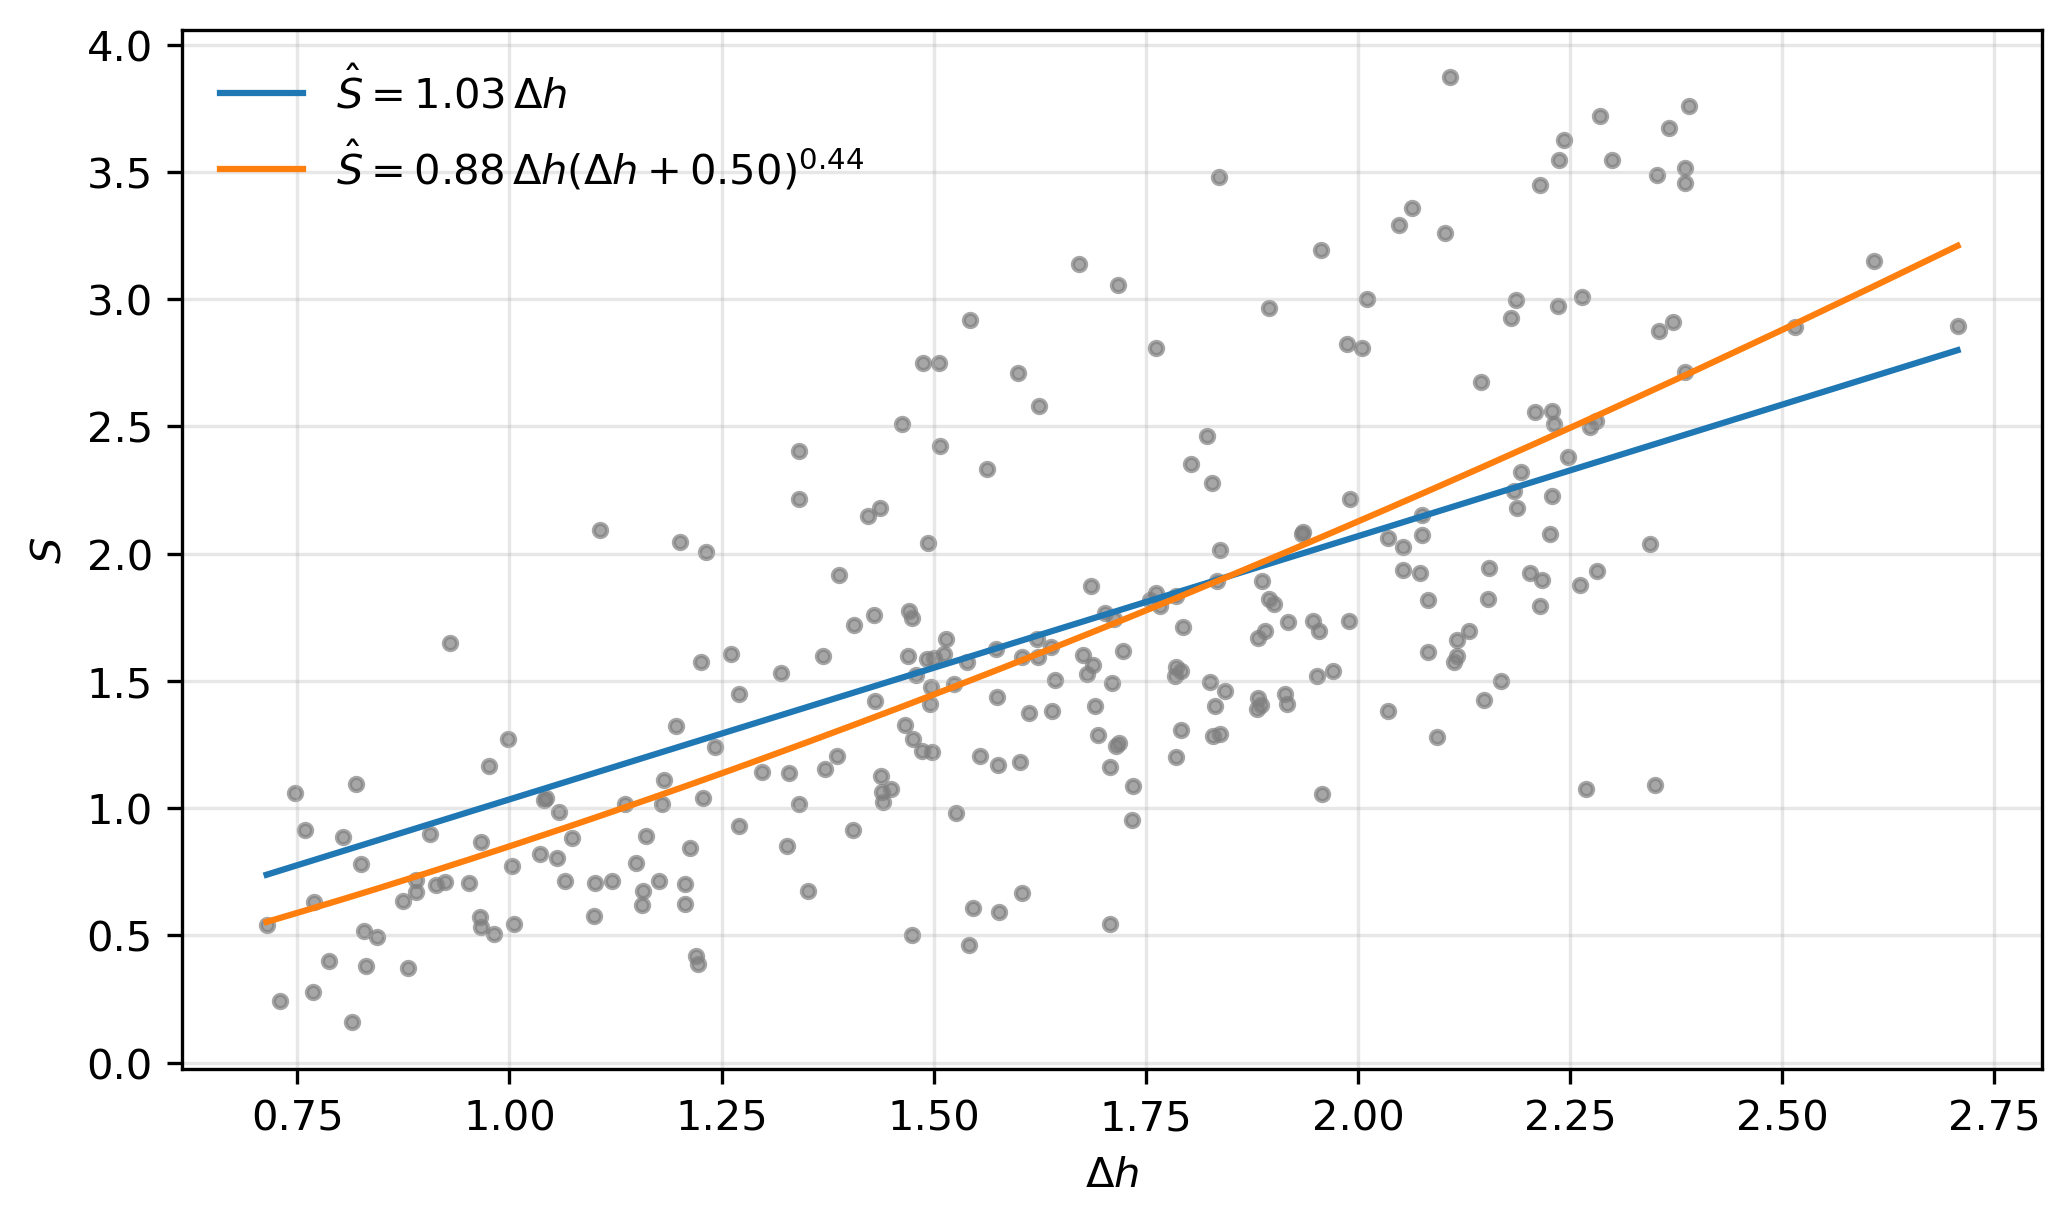

In [41]:

fig, ax = plt.subplots()
ax.scatter(x_all, y_all, s=10, c="0.5", alpha=0.7, label="")

order = np.argsort(x_all)
xs = x_all[order]
ax.plot(xs, model_linear([K_lin], xs), label=fr"$\hat S = {K_lin:.2f}\,\Delta h$")
ax.plot(xs, model_power_offset([K_pow, offset_pow, b_pow], xs),
        label=fr"$\hat S = {K_pow:.2f}\,\Delta h(\Delta h + {offset_pow:.2f})^{{{b_pow:.2f}}}$")

ax.set_xlabel(r"$\Delta h$")
ax.set_ylabel(r"$S$")
ax.legend(frameon=False)
plt.show()
